In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

In [100]:
# Load the dataset
file_path = "ObesityDataSet.csv"
df = pd.read_csv(file_path)

1. EDA

In [101]:
# 1. Tampilkan beberapa baris pertama dan informasi umum dataset
print("5 baris pertama:")
print(df.head(5))

5 baris pertama:
  Age  Gender Height Weight        CALC FAVC FCVC NCP  SCC SMOKE CH2O  \
0  21  Female   1.62     64          no   no    2   3   no    no    2   
1  21  Female   1.52     56   Sometimes   no    3   3  yes   yes    3   
2  23    Male    1.8     77  Frequently   no    2   3   no    no    2   
3  27    Male    1.8     87  Frequently   no    3   3   no    no    2   
4  22    Male   1.78   89.8   Sometimes   no    2   1   no    no    2   

  family_history_with_overweight FAF TUE       CAEC                 MTRANS  \
0                            yes   0   1  Sometimes  Public_Transportation   
1                            yes   3   0  Sometimes  Public_Transportation   
2                            yes   2   1  Sometimes  Public_Transportation   
3                             no   2   0  Sometimes                Walking   
4                             no   0   0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Weight  
1        Normal_Weight  


In [102]:
# Tampilkan jumlah baris dan kolom
print("\nJumlah baris dan kolom:")
print(f"{df.shape[0]} baris, {df.shape[1]} kolom")


Jumlah baris dan kolom:
2111 baris, 17 kolom


In [103]:
# Tipe data
df = df.replace('?', np.nan)
kolom_numerik = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for kol in kolom_numerik:
    df[kol] = pd.to_numeric(df[kol], errors='coerce')
print("\nTIPE DATA:")
print(df.dtypes)


TIPE DATA:
Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64
NCP                               float64
SCC                                object
SMOKE                              object
CH2O                              float64
family_history_with_overweight     object
FAF                               float64
TUE                               float64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


In [104]:
# Tampilkan deskripsi statistik data numerik
print("\nDeskripsi data numerik:")
print(df.describe())


Deskripsi data numerik:
               Age       Height       Weight         FCVC          NCP  \
count  2089.000000  2089.000000  2092.000000  2093.000000  2089.000000   
mean     24.717928     1.706623    88.608184     2.443519     2.729418   
std       8.391323     0.117700    36.154617     0.642754     0.981124   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.955257     1.630000    66.000000     2.000000     2.675411   
50%      22.814657     1.701284    83.000000     2.397284     3.000000   
75%      26.000000     1.770000   108.055736     3.000000     3.000000   
max     106.441252     2.853986   441.131078     8.706795    12.299828   

              CH2O          FAF          TUE  
count  2096.000000  2092.000000  2096.000000  
mean      2.030560     1.073435     0.680138  
std       0.737945     1.149364     0.717160  
min       1.000000     0.000000     0.000000  
25%       1.569911     0.129009     0.000000  
50%       2.000000     1.0

In [105]:
# Untuk data kategorikal juga bisa tambahkan:
print("\nDeskripsi data kategorikal:")
print(df.describe(include=['object']))


Deskripsi data kategorikal:
       Gender       CALC  FAVC   SCC SMOKE family_history_with_overweight  \
count    2089       2091  2089  2093  2098                           2088   
unique      2          4     2     2     2                              2   
top      Male  Sometimes   yes    no    no                            yes   
freq     1056       1386  1844  1997  2054                           1705   

             CAEC                 MTRANS      NObeyesdad  
count        2093                   2099            2111  
unique          4                      5               7  
top     Sometimes  Public_Transportation  Obesity_Type_I  
freq         1747                   1572             351  


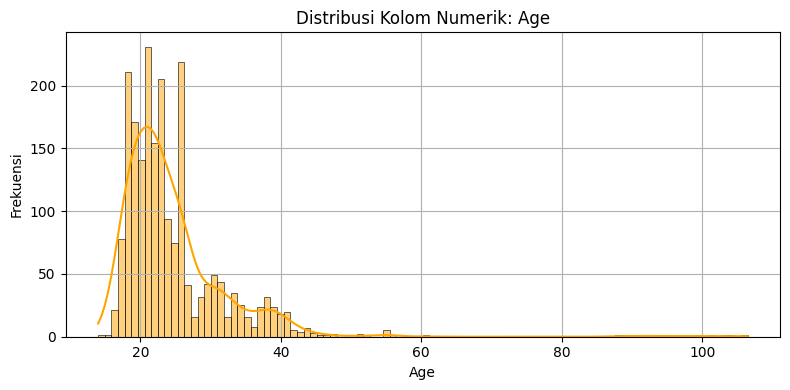

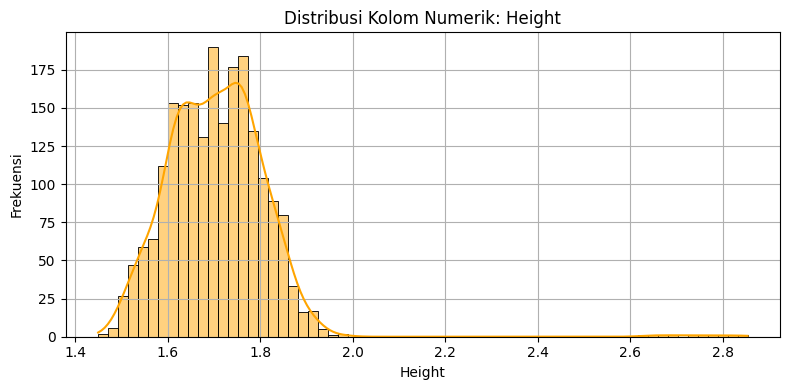

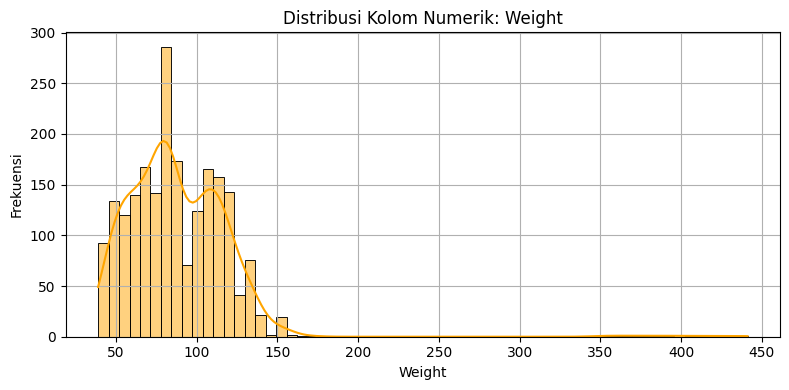

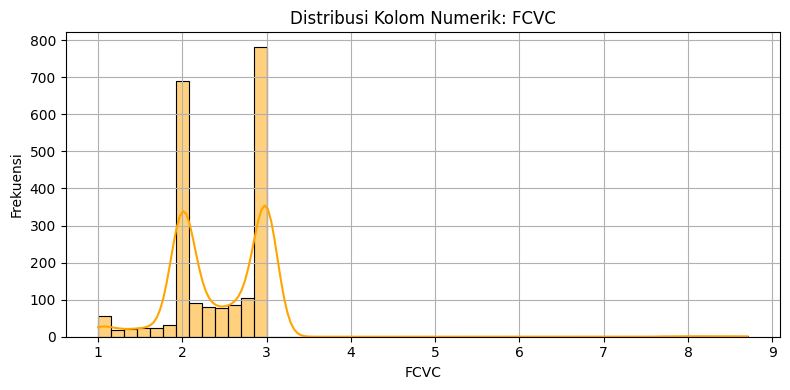

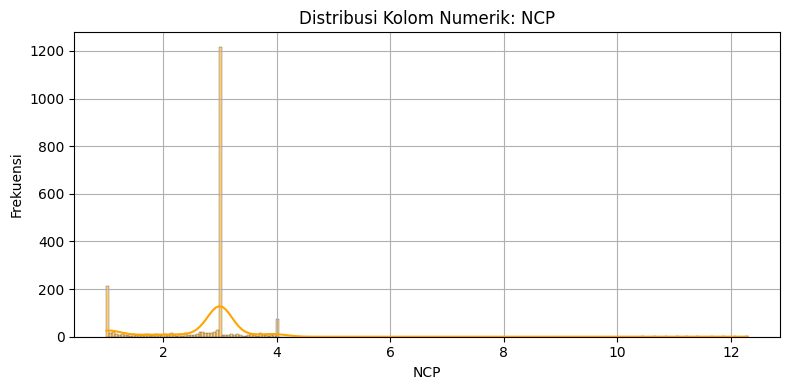

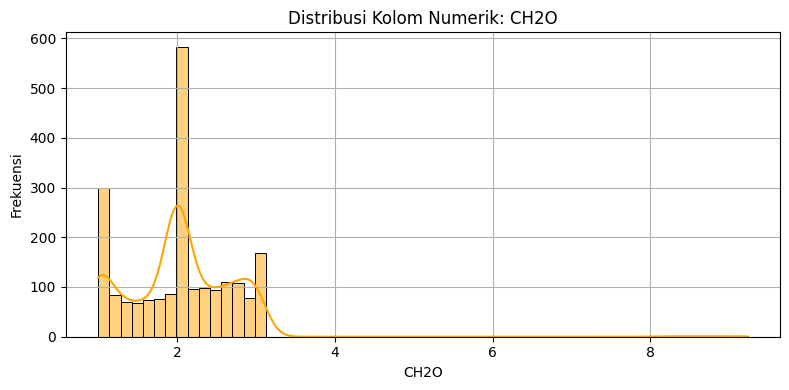

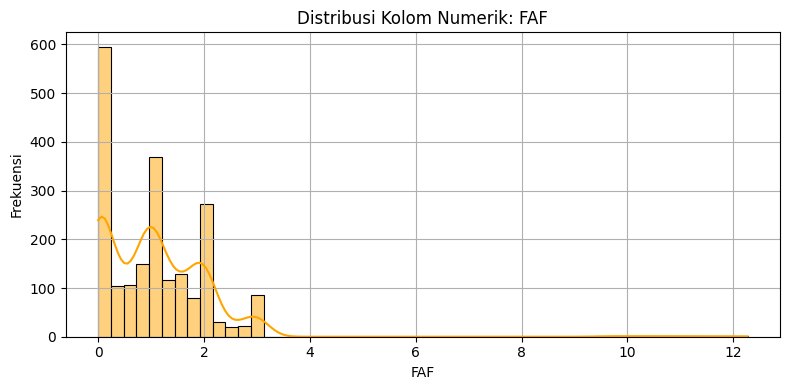

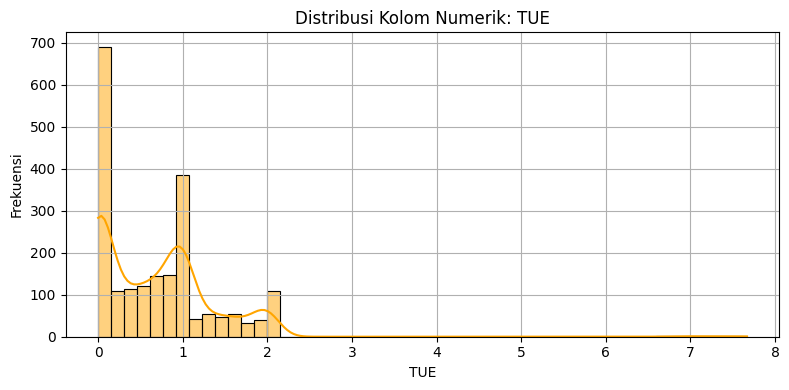

In [106]:
# Visualisasi kolom numerik
# Pilih kolom numerik
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Looping buat plot histogram tiap kolom numerik
for col in numerik_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='orange')
    plt.title(f'Distribusi Kolom Numerik: {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


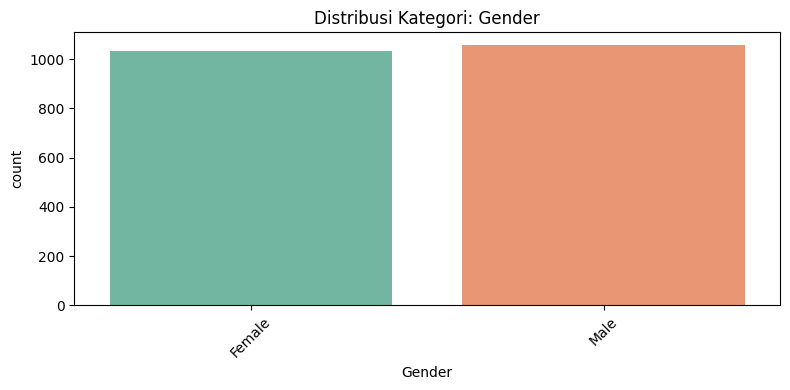

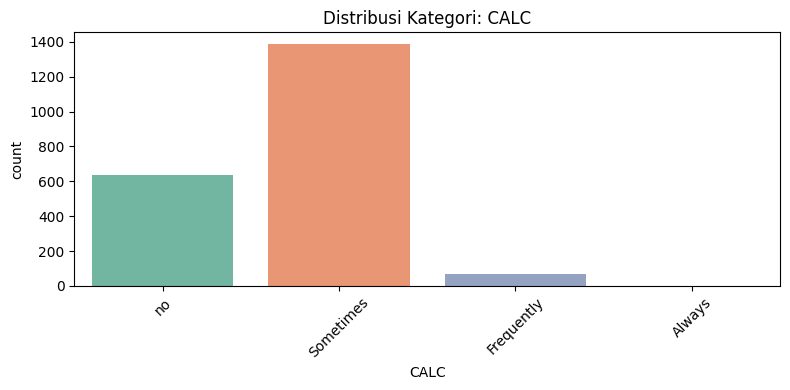

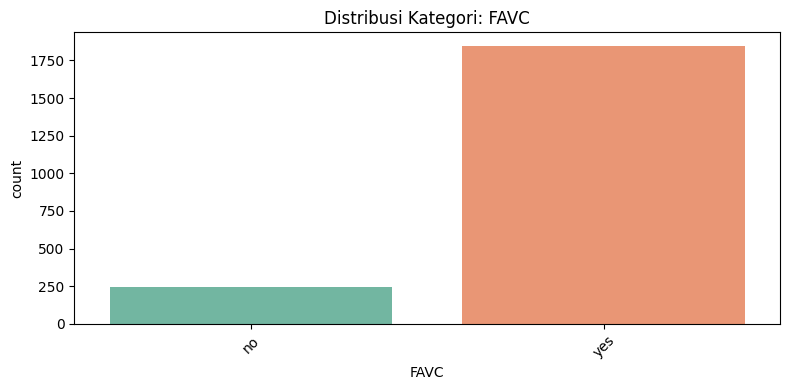

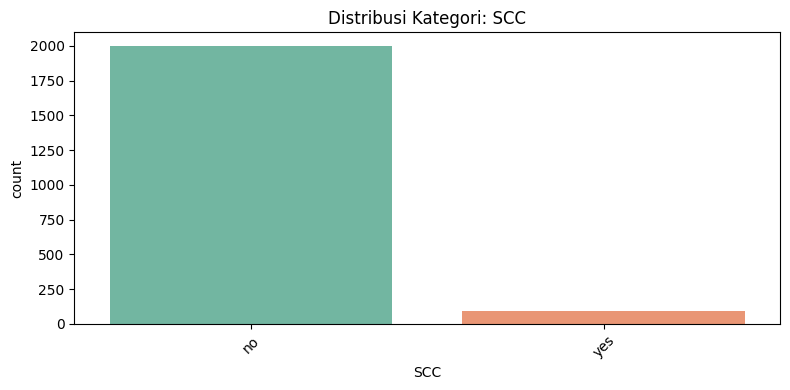

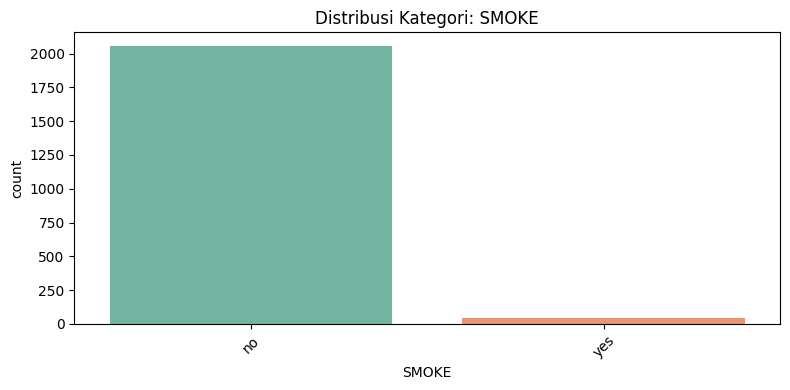

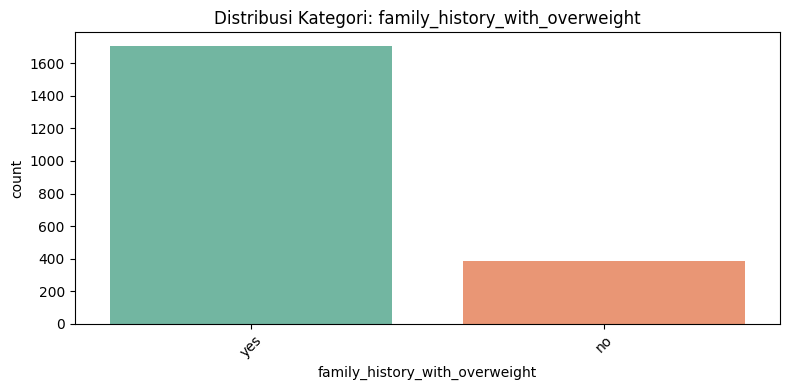

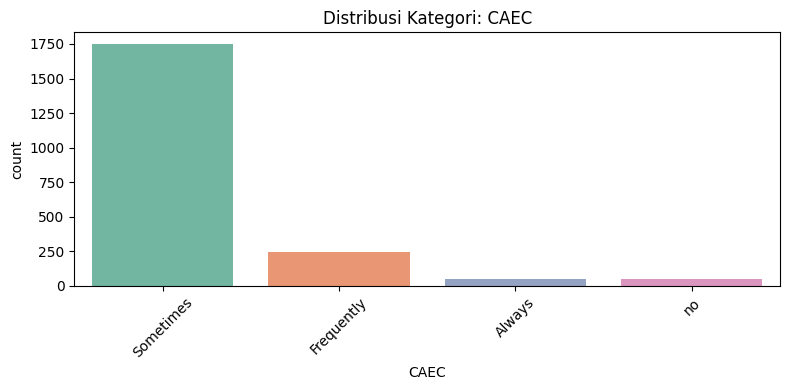

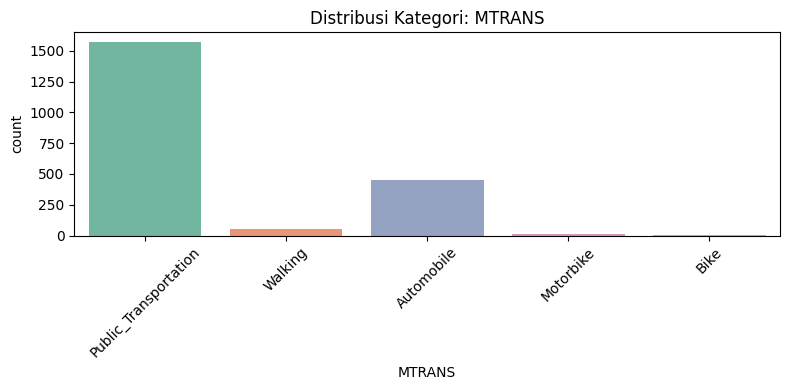

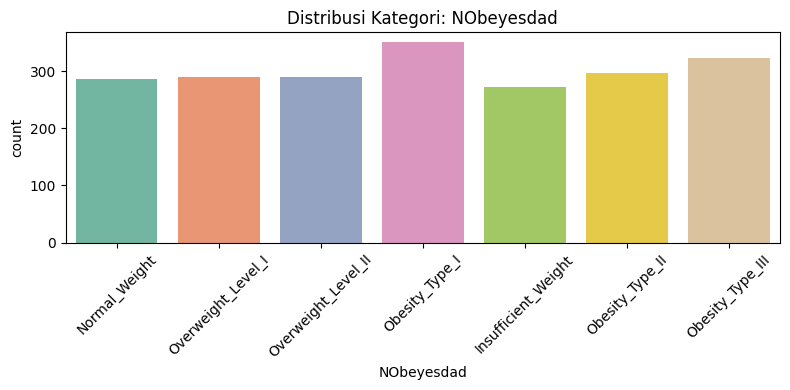

In [73]:
# Visualisasi kolom kategorikal

warnings.simplefilter(action='ignore', category=FutureWarning)

# Pilih kolom kategorikal
kategori_cols = df.select_dtypes(include=['object', 'category']).columns

# Looping buat plot countplot tiap kolom kategorikal
for col in kategori_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribusi Kategori: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [107]:
# Cek Missing Values
print("Cek Missing Values:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Cek Missing Values:
Age                               22
Gender                            22
Height                            22
Weight                            19
CALC                              20
FAVC                              22
FCVC                              18
NCP                               22
SCC                               18
SMOKE                             13
CH2O                              15
family_history_with_overweight    23
FAF                               19
TUE                               15
CAEC                              18
MTRANS                            12
NObeyesdad                         0
dtype: int64

Total missing values: 300


In [108]:
# Cek Unique Values per Kolom
print("\nCek Unique Values per Kolom:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Cek Unique Values per Kolom:
Age: 1393
Gender: 2
Height: 1561
Weight: 1517
CALC: 4
FAVC: 2
FCVC: 807
NCP: 636
SCC: 2
SMOKE: 2
CH2O: 1262
family_history_with_overweight: 2
FAF: 1185
TUE: 1129
CAEC: 4
MTRANS: 5
NObeyesdad: 7


In [109]:
# Cek Data Duplikat
print(f"Cek Jumlah data duplikat: {df.duplicated().sum()}")

Cek Jumlah data duplikat: 18


Keseimbangan Data - Kolom Kategorikal

Distribusi Gender:
Gender
Male      50.550503
Female    49.449497
Name: proportion, dtype: float64


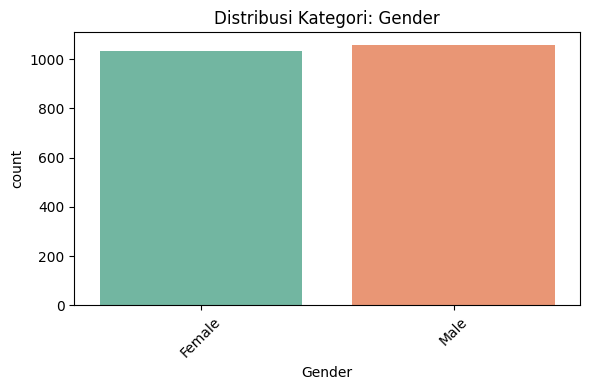


Distribusi CALC:
CALC
Sometimes     66.284075
no            30.320421
Frequently     3.347681
Always         0.047824
Name: proportion, dtype: float64


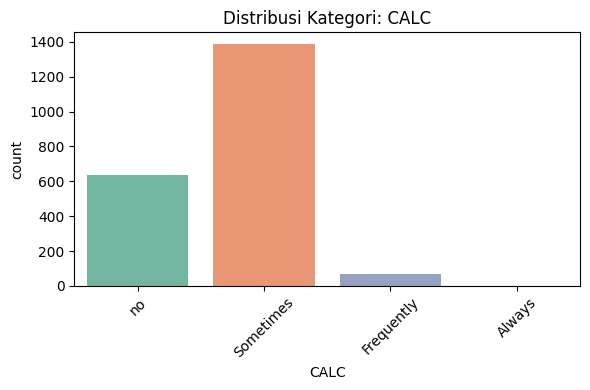


Distribusi FAVC:
FAVC
yes    88.2719
no     11.7281
Name: proportion, dtype: float64


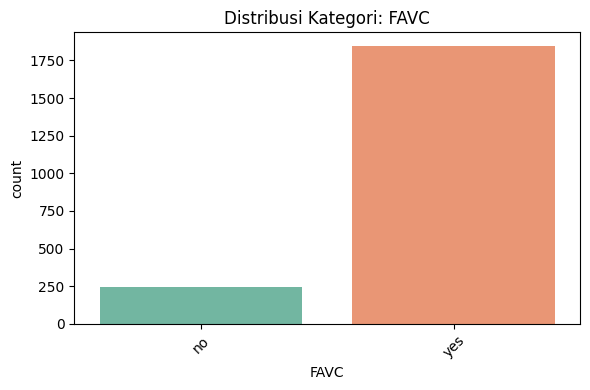


Distribusi SCC:
SCC
no     95.413282
yes     4.586718
Name: proportion, dtype: float64


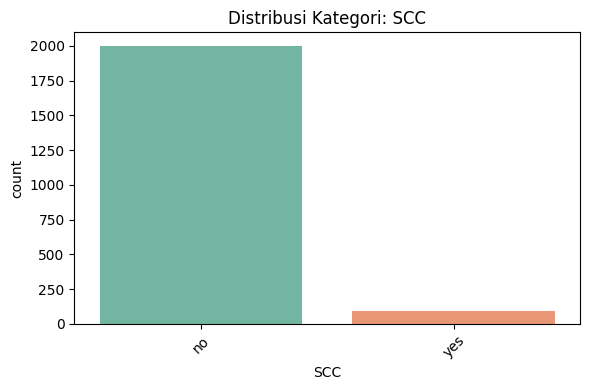


Distribusi SMOKE:
SMOKE
no     97.902765
yes     2.097235
Name: proportion, dtype: float64


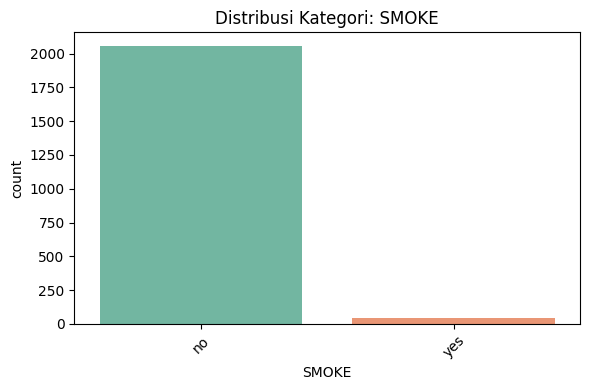


Distribusi family_history_with_overweight:
family_history_with_overweight
yes    81.657088
no     18.342912
Name: proportion, dtype: float64


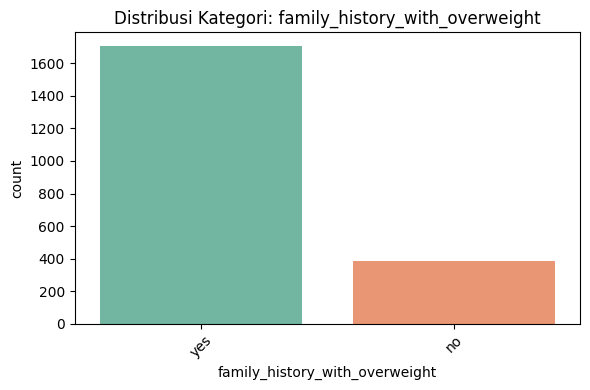


Distribusi CAEC:
CAEC
Sometimes     83.468705
Frequently    11.562351
Always         2.532250
no             2.436694
Name: proportion, dtype: float64


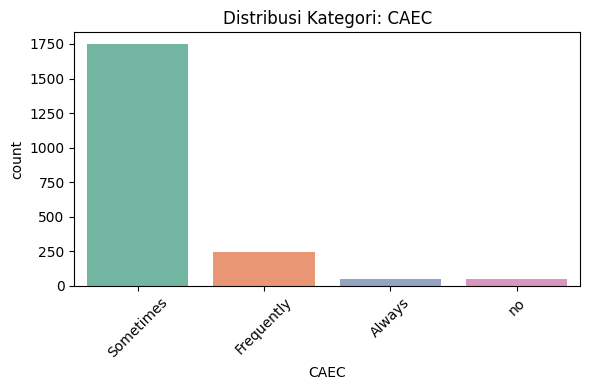


Distribusi MTRANS:
MTRANS
Public_Transportation    74.892806
Automobile               21.581706
Walking                   2.667937
Motorbike                 0.524059
Bike                      0.333492
Name: proportion, dtype: float64


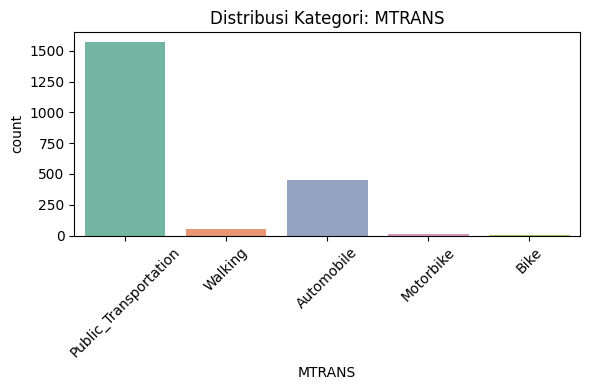


Distribusi NObeyesdad:
NObeyesdad
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


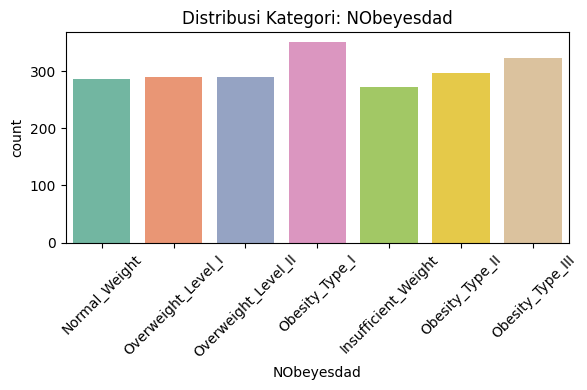


Keseimbangan Data - Kolom Numerik


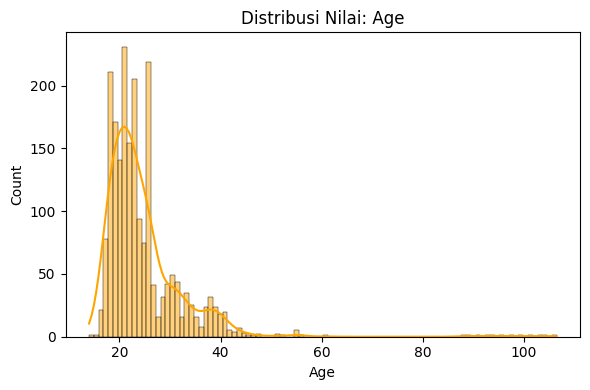

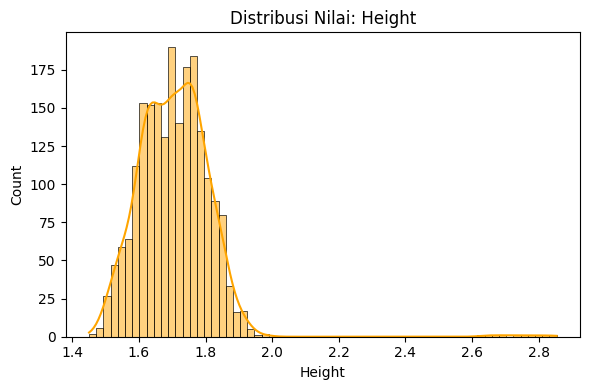

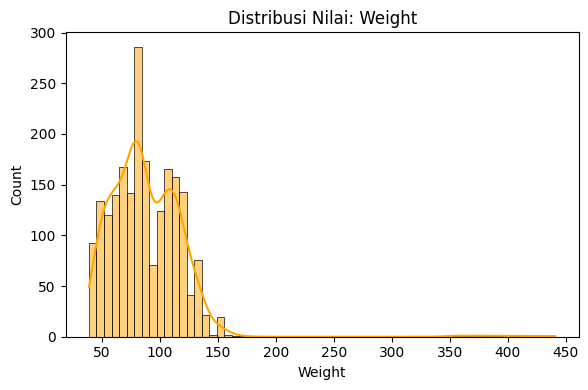

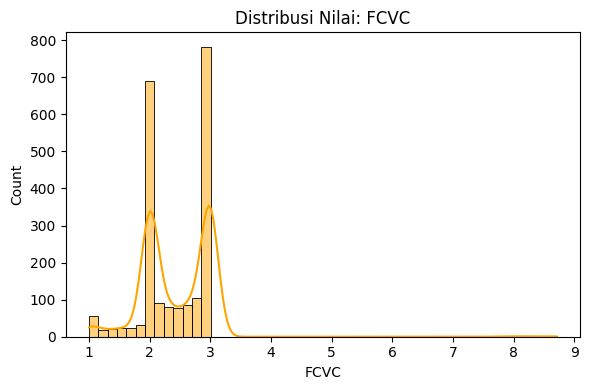

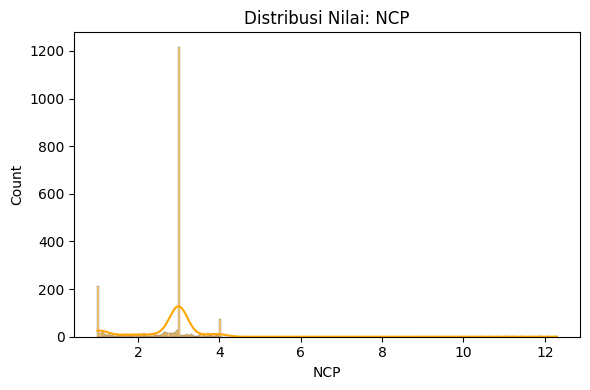

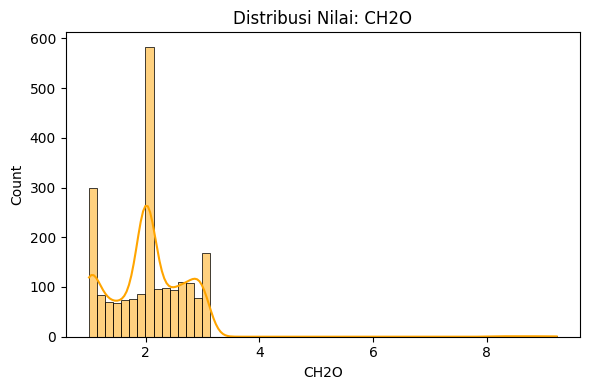

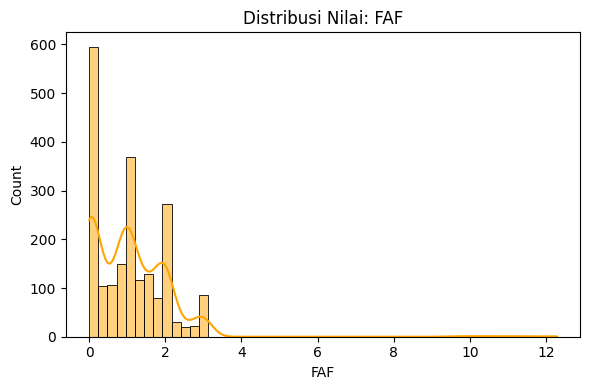

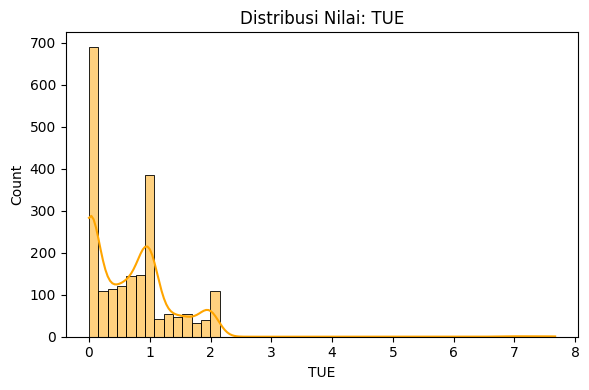

In [110]:
#Cek keseimbangan seluruh dataset

# Pisahkan kolom numerik & kategorikal
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns
kategori_cols = df.select_dtypes(include=['object', 'category']).columns

# Cek Keseimbangan Kolom Kategorikal
print("Keseimbangan Data - Kolom Kategorikal")
for col in kategori_cols:
    print(f"\nDistribusi {col}:")
    print(df[col].value_counts(normalize=True) * 100)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribusi Kategori: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Cek Keseimbangan Kolom Numerik
print("\nKeseimbangan Data - Kolom Numerik")
for col in numerik_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, color='orange')
    plt.title(f'Distribusi Nilai: {col}')
    plt.tight_layout()
    plt.show()



Deteksi Outlier Kolom Numerik dengan Boxplot


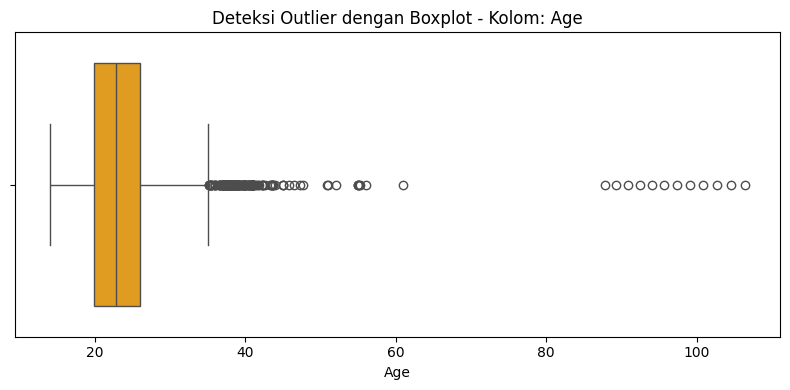

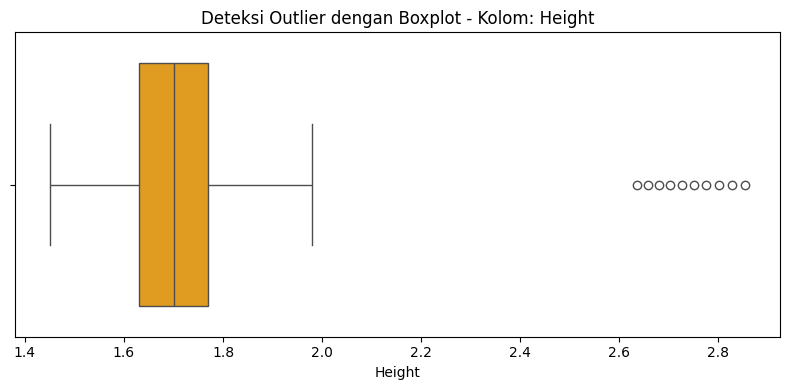

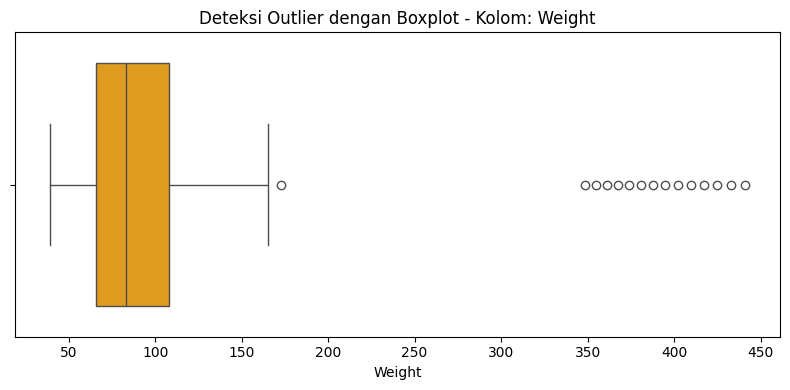

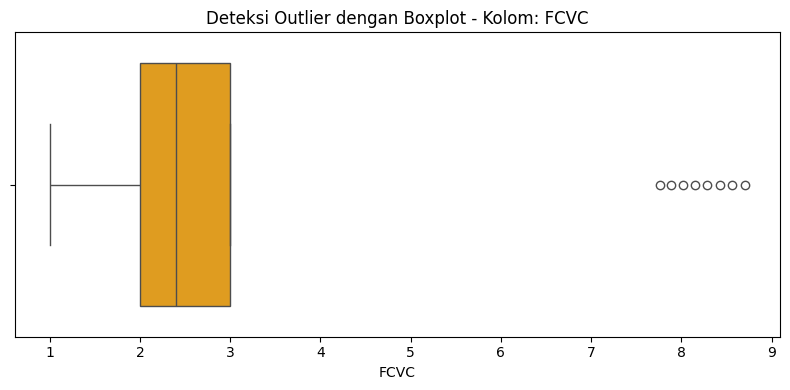

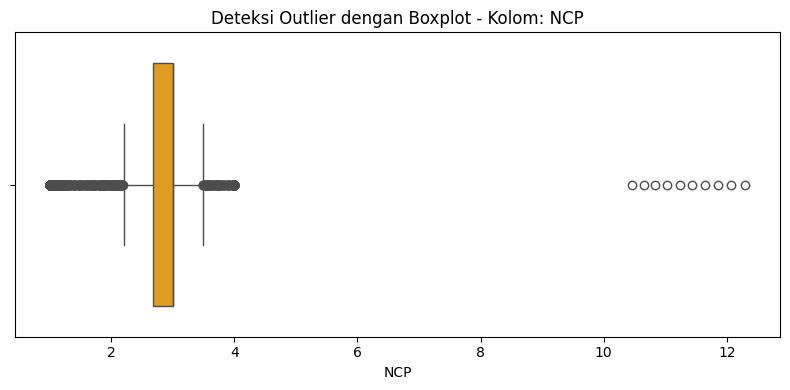

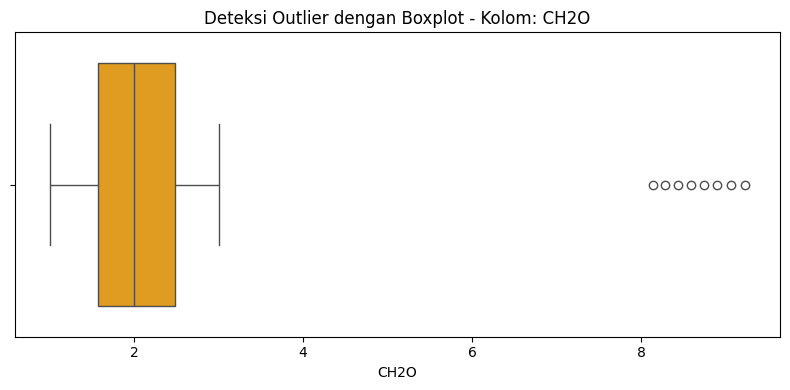

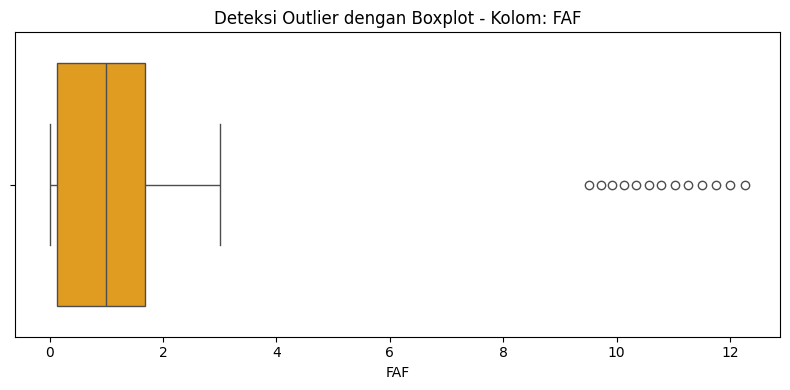

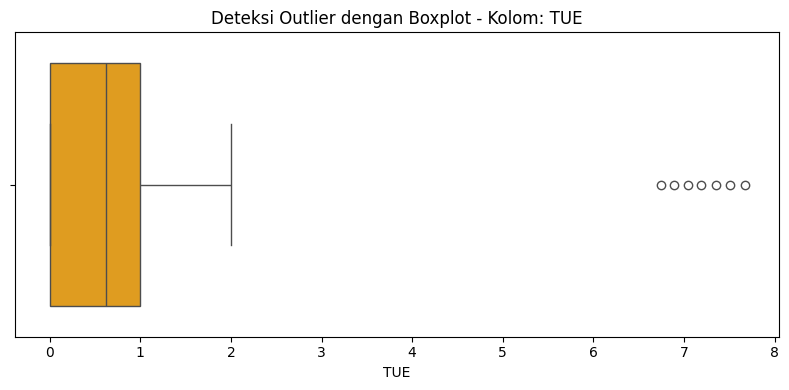

In [111]:
# Deteksi outlier kolom numerik menggunakan boxplot
print("\nDeteksi Outlier Kolom Numerik dengan Boxplot")
# Pilih kolom numerik
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Buat boxplot tiap kolom numerik untuk deteksi outlier
for col in numerik_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Deteksi Outlier dengan Boxplot - Kolom: {col}')
    plt.tight_layout()
    plt.show()



Kesimpulan:

Dataset ini terdiri dari 2111 baris dan 17 kolom yang meliputi berbagai atribut seperti Age, Gender, Height, Weight, CALC, FAVC, FCVC, NCP, SCC, SMOKE, CH2O, family\_history\_with\_overweight, FAF, TUE, CAEC, MTRANS, dan NObeyesdad. Dalam proses eksplorasi data ditemukan adanya 300 nilai missing yang tersebar di seluruh kolom serta 18 baris data duplikat yang perlu diatasi agar kualitas data tetap terjaga. Selain itu, deteksi outlier dilakukan khusus pada kolom numerik yaitu Age, Height, Weight, FCVC, NCP, CH2O, FAF, dan TUE menggunakan boxplot untuk mengidentifikasi nilai-nilai ekstrim yang berpotensi memengaruhi analisis lebih lanjut.


2. Preprocessing Data 

In [112]:
# Cek missing values dan imputasi
# Contoh pendekatan sederhana: Imputasi berdasarkan tipe data
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"Kolom '{col}' (tipe object) diisi dengan modus: {mode_val}")
        else:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"Kolom '{col}' (tipe numerik) diisi dengan median: {median_val}")


Kolom 'Age' (tipe numerik) diisi dengan median: 22.814657
Kolom 'Gender' (tipe object) diisi dengan modus: Male
Kolom 'Height' (tipe numerik) diisi dengan median: 1.701284
Kolom 'Weight' (tipe numerik) diisi dengan median: 83.0
Kolom 'CALC' (tipe object) diisi dengan modus: Sometimes
Kolom 'FAVC' (tipe object) diisi dengan modus: yes
Kolom 'FCVC' (tipe numerik) diisi dengan median: 2.397284
Kolom 'NCP' (tipe numerik) diisi dengan median: 3.0
Kolom 'SCC' (tipe object) diisi dengan modus: no
Kolom 'SMOKE' (tipe object) diisi dengan modus: no
Kolom 'CH2O' (tipe numerik) diisi dengan median: 2.0
Kolom 'family_history_with_overweight' (tipe object) diisi dengan modus: yes
Kolom 'FAF' (tipe numerik) diisi dengan median: 1.0
Kolom 'TUE' (tipe numerik) diisi dengan median: 0.6253605
Kolom 'CAEC' (tipe object) diisi dengan modus: Sometimes
Kolom 'MTRANS' (tipe object) diisi dengan modus: Public_Transportation


In [113]:
print("\nMissing value setelah imputasi:")
print(df.isnull().sum())
print("Total:", df.isnull().sum().sum())



Missing value setelah imputasi:
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Total: 0


In [115]:
# Tangani Duplikat
print(f"\nJumlah Duplikasi Sebelum: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Jumlah Duplikasi Setelah: {df.duplicated().sum()}")


Jumlah Duplikasi Sebelum: 0
Jumlah Duplikasi Setelah: 0


In [116]:
# Tangani Eror (Contoh validasi kolom numerik tidak bernilai negatif (misalnya kolom umur atau harga))
for col in df.select_dtypes(include=np.number).columns:
    if (df[col] < 0).any():
        print(f"Error nilai negatif ditemukan di kolom: {col}, akan diganti dengan median")
        df.loc[df[col] < 0, col] = df[col].median()


In [117]:
# Tangani Outlier
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Terapkan pada semua kolom numerik
for col in df.select_dtypes(include=np.number).columns:
    original_len = len(df)
    df = remove_outliers_iqr(df, col)
    print(f"Outlier dihapus dari kolom '{col}': {original_len - len(df)} baris")

Outlier dihapus dari kolom 'Age': 179 baris
Outlier dihapus dari kolom 'Height': 12 baris
Outlier dihapus dari kolom 'Weight': 14 baris
Outlier dihapus dari kolom 'FCVC': 6 baris
Outlier dihapus dari kolom 'NCP': 545 baris
Outlier dihapus dari kolom 'CH2O': 5 baris
Outlier dihapus dari kolom 'FAF': 9 baris
Outlier dihapus dari kolom 'TUE': 5 baris


In [118]:
# Cek kolom kategorik
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Kolom kategorik:", list(categorical_cols))

# Pilih metode
if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("Semua kolom kategorik diubah jadi numerik dengan one-hot encoding.")
else:
    print("Tidak ada kolom kategorik yang perlu dikonversi.")


Kolom kategorik: ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS', 'NObeyesdad']
Semua kolom kategorik diubah jadi numerik dengan one-hot encoding.


In [119]:
print(df.info())  # semua kolom sekarang numerik (int/float)


<class 'pandas.core.frame.DataFrame'>
Index: 1316 entries, 0 to 2110
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 1316 non-null   float64
 1   Height                              1316 non-null   float64
 2   Weight                              1316 non-null   float64
 3   FCVC                                1316 non-null   float64
 4   NCP                                 1316 non-null   float64
 5   CH2O                                1316 non-null   float64
 6   FAF                                 1316 non-null   float64
 7   TUE                                 1316 non-null   float64
 8   Gender_Male                         1316 non-null   bool   
 9   CALC_Sometimes                      1316 non-null   bool   
 10  CALC_no                             1316 non-null   bool   
 11  FAVC_yes                            1316 non-nul

In [ ]:
# tentukan apakah semua feature perlu digunakan. 

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # Fitur dengan variansi < 1% dibuang
selector.fit(df.drop('NObeyesdad_Overweight_Level_II', axis=1))

low_variance_features = df.drop('NObeyesdad_Overweight_Level_II', axis=1).columns[~selector.get_support()]
print("Fitur variansi rendah:", list(low_variance_features))


Fitur variansi rendah: ['Height', 'MTRANS_Bike', 'MTRANS_Motorbike']


fitur-fitur ini kemungkinan besar tidak banyak memberi informasi tambahan, karena nilainya hampir sama di semua baris.

In [121]:
df = df.drop(['Height', 'MTRANS_Bike', 'MTRANS_Motorbike'], axis=1)
print("Fitur variansi rendah sudah dihapus.")


Fitur variansi rendah sudah dihapus.


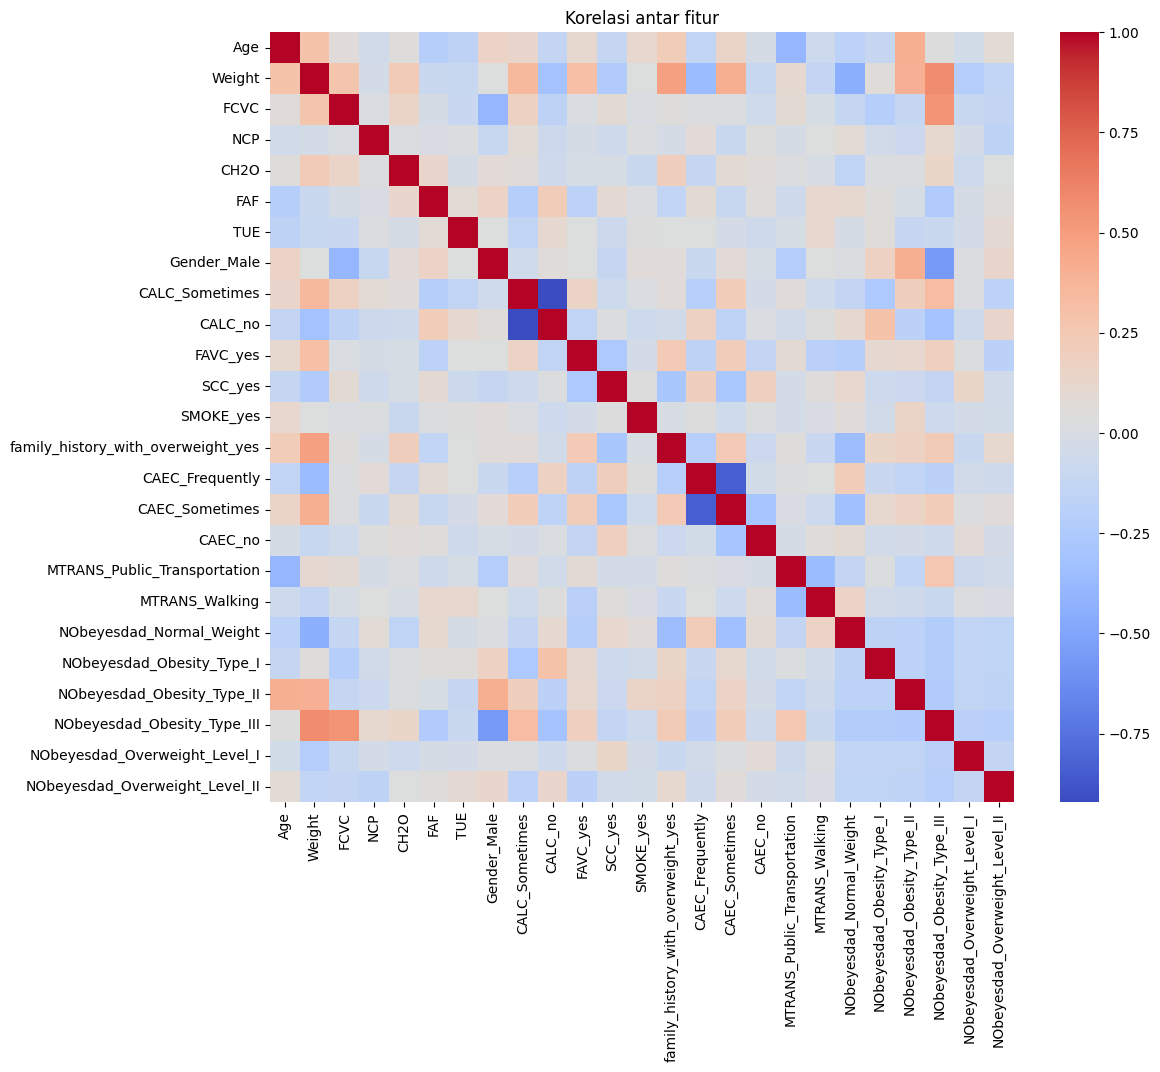

In [122]:

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Korelasi antar fitur")
plt.show()


In [123]:
print(df['NObeyesdad_Overweight_Level_II'].value_counts())
print(df['NObeyesdad_Overweight_Level_II'].value_counts(normalize=True))  # dalam persen


NObeyesdad_Overweight_Level_II
False    1159
True      157
Name: count, dtype: int64
NObeyesdad_Overweight_Level_II
False    0.880699
True     0.119301
Name: proportion, dtype: float64


tidak seimbang.
Kelas True (Overweight Level II) cuma 12%, artinya model bisa bias ke kelas False.

In [133]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Pisah fitur dan target
X = df.drop('NObeyesdad_Overweight_Level_II', axis=1)
y = df['NObeyesdad_Overweight_Level_II']

# Bagi dulu ke training & test (biar SMOTE cuma dipakai di training)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Cek hasil distribusi baru
print("Sebelum SMOTE:\n", y_train.value_counts())
print("Sesudah SMOTE:\n", y_train_smote.value_counts())


ModuleNotFoundError: No module named 'imblearn'